In [34]:
import pandas as pd
import re

from sklearn.feature_extraction.text import TfidfVectorizer

In [35]:
df = pd.read_csv(
    "../data/raw/Student_Feedback.csv",
    encoding="latin-1"
)

print("Original shape:", df.shape)

Original shape: (1086, 2)


In [36]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [37]:
df["cleaned_text"] = df["comments"].apply(clean_text)

display(
    df[["comments", "cleaned_text"]].head(10)
)

,comments,cleaned_text
0,TEACHERS HELP US IN CAREER BUILDING,teachers help us in career building
1,Having no technical knowledge about their taug...,having no technical knowledge about their taug...
2,teacher should give us the practical knowledge...,teacher should give us the practical knowledge...
3,better teaching methodology,better teaching methodology
4,best teaching method,best teaching method
5,teaching method is very tough and very diffcul...,teaching method is very tough and very diffcul...
6,THEY IMPART modern and latest knowledge to us,they impart modern and latest knowledge to us
7,teachers give us all the required information ...,teachers give us all the required information ...
8,Your teaching style is engaging,your teaching style is engaging
9,least EXPOSURE to modern trends discussed,least exposure to modern trends discussed


In [38]:
df_model = df.drop_duplicates(
    subset="cleaned_text"
).copy()

print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df_model))

Original rows: 1086
Rows after removing duplicates: 1061


In [39]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=3000
)

X_tfidf = vectorizer.fit_transform(
    df_model["cleaned_text"]
)

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (1061, 3000)


In [40]:
feature_names = vectorizer.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 50 features:")
print(feature_names[:50])

Number of features: 3000

First 50 features:
['about' 'about class' 'about comptuers' 'about computer'
 'about computers' 'about gaining' 'about high' 'about html'
 'about humanity' 'about it' 'about many' 'about min' 'about modern'
 'about our' 'about programing' 'about programming' 'about the'
 'about this' 'about your' 'above' 'academic' 'accurate' 'activities'
 'afraid' 'afraid of' 'after' 'after you' 'again' 'all' 'all because'
 'all equal' 'all lectures' 'all of' 'all teachers' 'all the' 'allah'
 'allah bless' 'allocation' 'allow' 'also' 'alvi' 'always' 'always late'
 'always ready' 'am' 'am not' 'am weak' 'amicable' 'an' 'an excellent']


In [41]:
sample_index = 0

sample_vector = X_tfidf[sample_index]

print("Number of non-zero features:",
      sample_vector.nnz)

Number of non-zero features: 9


In [42]:
sample_index = 0

sample_vector = X_tfidf[sample_index]

nonzero_indices = sample_vector.nonzero()[1]

for index in nonzero_indices:
    print(
        feature_names[index],
        "→",
        sample_vector[0, index]
    )

teachers → 0.16490329371209056
help → 0.33232490582478513
us → 0.19715529105244062
in → 0.17525896327511056
career → 0.4098442982077198
teachers help → 0.4098442982077198
help us → 0.3926802625601247
us in → 0.33801141701332754
in career → 0.43403564774199077


In [43]:
print("Original comment:")
print(df_model.iloc[sample_index]["comments"])

print("\nCleaned comment:")
print(df_model.iloc[sample_index]["cleaned_text"])

Original comment:
TEACHERS HELP US IN CAREER BUILDING

Cleaned comment:
teachers help us in career building


In [44]:
sample_index = 0

row = X_tfidf[sample_index].toarray().flatten()

top_indices = row.argsort()[-10:][::-1]

for index in top_indices:
    if row[index] > 0:
        print(
            f"{feature_names[index]:25s} → {row[index]:.4f}"
        )

in career                 → 0.4340
teachers help             → 0.4098
career                    → 0.4098
help us                   → 0.3927
us in                     → 0.3380
help                      → 0.3323
us                        → 0.1972
in                        → 0.1753
teachers                  → 0.1649


In [45]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = list(
    set(ENGLISH_STOP_WORDS) - {
        "not",
        "no",
        "nor",
        "never"
    }
)

print("Total custom stopwords:", len(custom_stopwords))

Total custom stopwords: 314


In [46]:
tfidf_custom = TfidfVectorizer(
    stop_words=custom_stopwords,
    ngram_range=(1, 2),
    max_features=3000
)

In [47]:
X_tfidf_custom = tfidf_custom.fit_transform(
    df_model["cleaned_text"]
)

print("TF-IDF matrix shape:", X_tfidf_custom.shape)

TF-IDF matrix shape: (1061, 3000)


In [48]:
original_features = set(vectorizer.get_feature_names_out())
custom_features = set(tfidf_custom.get_feature_names_out())

print("Original vocabulary size:", len(original_features))
print("Custom vocabulary size:", len(custom_features))

print("\nFeatures removed:")
print(sorted(original_features - custom_features)[:50])

Original vocabulary size: 3000
Custom vocabulary size: 3000

Features removed:
['about', 'about class', 'about comptuers', 'about computer', 'about computers', 'about gaining', 'about high', 'about html', 'about humanity', 'about it', 'about many', 'about min', 'about modern', 'about our', 'about programing', 'about programming', 'about the', 'about this', 'about your', 'above', 'afraid of', 'after', 'after you', 'again', 'all', 'all because', 'all equal', 'all lectures', 'all of', 'all teachers', 'all the', 'also', 'always', 'always late', 'always ready', 'am', 'am not', 'am weak', 'an', 'an excellent', 'and', 'and about', 'and all', 'and at', 'and cooperative', 'and do', 'and encourage', 'and hard', 'and more', 'and programming']


In [49]:
custom_features = set(tfidf_custom.get_feature_names_out())

for word in ["not", "no", "nor", "never"]:
    print(word, word in custom_features)

not True
no True
nor False
never True


In [50]:
feature_names_custom = tfidf_custom.get_feature_names_out()

sample_index = 0
row = X_tfidf_custom[sample_index].toarray().flatten()

top_indices = row.argsort()[-10:][::-1]

print("Comment:")
print(df_model.iloc[sample_index]["comments"])

print("\nTop TF-IDF features:")

for index in top_indices:
    if row[index] > 0:
        print(
            f"{feature_names_custom[index]:25s} → {row[index]:.4f}"
        )

Comment:
TEACHERS HELP US IN CAREER BUILDING

Top TF-IDF features:
help career               → 0.4259
career building           → 0.4259
building                  → 0.4259
teachers help             → 0.4021
career                    → 0.4021
help                      → 0.3261
teachers                  → 0.1618


In [51]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [52]:
k_values = range(2, 9)

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_tfidf_custom)
    
    score = silhouette_score(
        X_tfidf_custom,
        labels
    )
    
    silhouette_scores.append(score)
    
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.0073
K = 3, Silhouette Score = 0.0082
K = 4, Silhouette Score = 0.0097
K = 5, Silhouette Score = 0.0107
K = 6, Silhouette Score = 0.0113
K = 7, Silhouette Score = 0.0146
K = 8, Silhouette Score = 0.0144


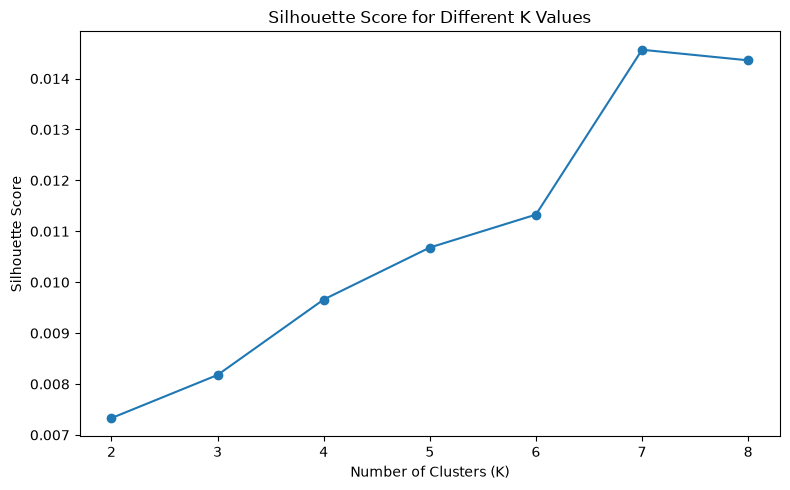

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.xticks(list(k_values))

plt.tight_layout()
plt.savefig("../results/figures/tfidf_silhouette_scores.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
best_k = 7

kmeans_tfidf = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

tfidf_labels = kmeans_tfidf.fit_predict(X_tfidf_custom)

df_model["tfidf_cluster"] = tfidf_labels

print(df_model["tfidf_cluster"].value_counts().sort_index())

tfidf_cluster
0     72
1    153
2    458
3    123
4     27
5     73
6    155
Name: count, dtype: int64


In [29]:
feature_names = tfidf_custom.get_feature_names_out()

order_centroids = kmeans_tfidf.cluster_centers_.argsort(axis=1)[:, ::-1]

for cluster in range(best_k):
    print(f"\n{'=' * 60}")
    print(f"CLUSTER {cluster}")
    print(f"{'=' * 60}")
    
    top_terms = [
        feature_names[index]
        for index in order_centroids[cluster, :15]
    ]
    
    print(", ".join(top_terms))


CLUSTER 0
sir, teach, great, students, like, thank, wish, semester, level, great sir, lot, afraid sir, afraid, teach semester, alvi

CLUSTER 1
teachers, work, students, practical, practical work, lab, lab work, lectures, teachers discourage, discourage, nepotism, improve, teachers punctual, problems, teachers friendly

CLUSTER 2
students, teaches, good, knowledge, class, lectures, faculty, subject, learnt, like, skills, programming, student, learning, learn

CLUSTER 3
teacher, good teacher, students, good, excellent teacher, excellent, not, teacher not, teacher good, strict, class, subject, nice, student, discourages

CLUSTER 4
taught, sir taught, sir, topic taught, not taught, want, taught data, topic, world talking, data, lot sir, paper taught, not, excited, excited taught

CLUSTER 5
teaching, good, method, teaching method, methodology, teaching style, teaching methodology, style, way, teaching good, way teaching, method teaching, good teaching, excellent, methodology good

CLUSTER 

In [32]:
for cluster in range(best_k):
    print(f"\n{'=' * 50}")
    print(f"CLUSTER {cluster} | SIZE: {(df_model['tfidf_cluster'] == cluster).sum()}")
    print(f"{'=' * 50}")
    
    comments = df_model[
        df_model["tfidf_cluster"] == cluster
    ]["cleaned_text"].head(5)
    
    for i, comment in enumerate(comments, 1):
        print(f"{i}. {comment}")


CLUSTER 0 | SIZE: 72
1. teacher teach related to field
2. teach students above their level
3. teachers should teach us not slide the sldies
4. you teach motivate and encourage
5. i will remain in touch with you sir you are a good motivator

CLUSTER 1 | SIZE: 153
1. teachers help us in career building
2. teachers give us all the required information to improve the performance
3. teachers turn down the leave
4. less attention is given towards practical work
5. teachers should look into the financial matter of the students

CLUSTER 2 | SIZE: 458
1. they impart modern and latest knowledge to us
2. least exposure to modern trends discussed
3. you give proper important to it
4. you make learning a truly enjoyable experience
5. you have a gift for simplifying complex topics

CLUSTER 3 | SIZE: 123
1. teacher should give us the practical knowledge other than theortical
2. teacher was kind
3. even when we asked some irrelevant question teacher gave proper attention to them
4. teacher sometimes 

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_compare = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=3000
)

X_tfidf_compare = tfidf_compare.fit_transform(
    df_model["comments"]
)

print("TF-IDF matrix shape:", X_tfidf_compare.shape)

TF-IDF matrix shape: (1061, 3000)
